In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [7]:
#Load dataset
df = pd.read_csv("data.csv")


In [11]:
#Select target column
y = df["death"]

In [ ]:
#Drop unnecessary
X = df.drop(columns=[
    "death",              
    "recovered",          
    "date_of_recovery",   
    "date_of_death",      
    "days_to_recovery",   
    "patient_id",         
    "source_url"          
], errors="ignore")

In [9]:
#Convert categorical columns into numbers
X = pd.get_dummies(X, drop_first=True)

#Fill missing values
X = X.fillna(0)


In [12]:
#Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
#Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [14]:
#Train the model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
#Predict
y_pred = model.predict(X_test)

In [16]:
#Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.755

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.08      0.14        49
           1       0.77      0.97      0.86       151

    accuracy                           0.76       200
   macro avg       0.63      0.53      0.50       200
weighted avg       0.70      0.76      0.68       200

Confusion Matrix:

[[  4  45]
 [  4 147]]


                         Feature  Importance
1                            age    0.117545
0                  date_reported    0.087766
5                tests_conducted    0.040847
4             ventilator_support    0.023160
43       vaccination_status_Full    0.019411
55                 test_type_PCR    0.018976
20                   gender_Male    0.018234
46               variant_Omicron    0.017403
3                  icu_admission    0.016933
49  treatment_given_1_Remdesivir    0.016930


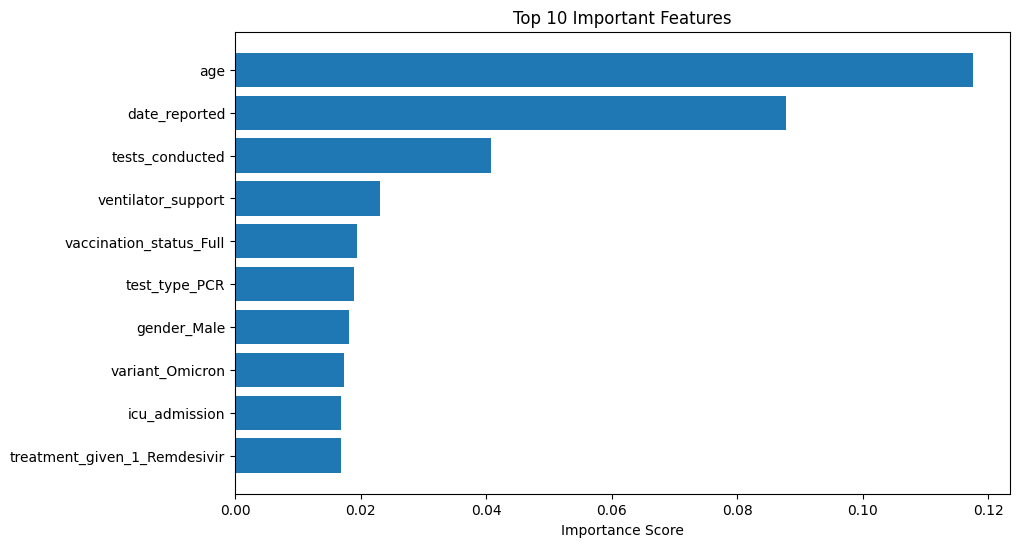

In [17]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"].head(10), importance_df["Importance"].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

In [18]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 20, 'n_estimators': 200}


In [19]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

In [20]:
print("Best Accuracy:", grid.best_score_)

Best Accuracy: 0.7649999999999999


In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
plt.imshow(df.corr(), cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.title("Feature Correlation Heatmap")
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)
plt.show()

ValueError: could not convert string to float: 'P000001'

<Figure size 1200x1000 with 0 Axes>

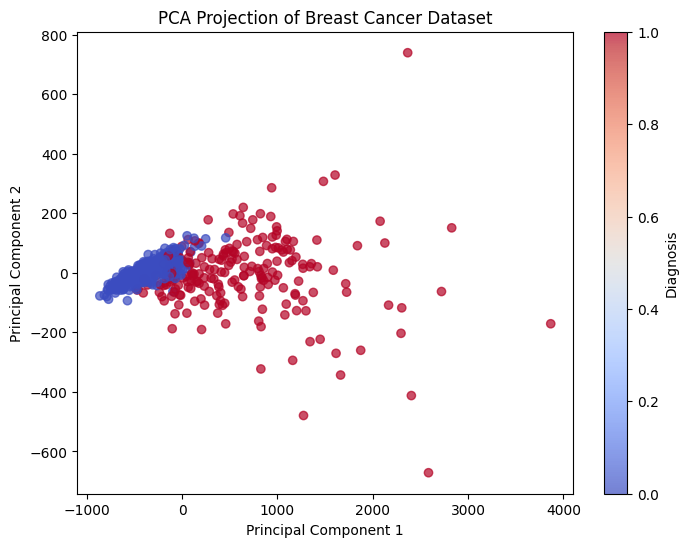

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title("PCA Projection of Breast Cancer Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Diagnosis")
plt.show()